data understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("Task 3 and 4_Loan_Data.csv")
fico   = df["fico_score"].values
target = df["default"].values
 
print("=" * 65)
print("  FICO SCORE BUCKETING — MSE & LOG-LIKELIHOOD (DP)")
print("=" * 65)
print(f"\nTotal borrowers : {len(fico):,}")
print(f"FICO range      : {fico.min()} – {fico.max()}")
print(f"Default rate    : {target.mean():.2%}")

  FICO SCORE BUCKETING — MSE & LOG-LIKELIHOOD (DP)

Total borrowers : 10,000
FICO range      : 408 – 850
Default rate    : 18.51%


build rating map 

In [7]:
def build_rating_map(boundaries: list, fico_arr, default_arr, label="") -> pd.DataFrame:
    """
    Given a sorted list of boundary points (including min and max),
    compute per-bucket stats and assign ratings.
    Rating 1 = best (highest FICO, lowest PD).
    """
    rows = []
    n_buckets = len(boundaries) - 1
    for i in range(n_buckets):
        lo, hi = boundaries[i], boundaries[i + 1]
        mask = (fico_arr >= lo) & (fico_arr < hi if i < n_buckets - 1 else fico_arr <= hi)
        n = mask.sum()
        k = default_arr[mask].sum()
        p = k / n if n > 0 else 0
        rows.append({
            "Rating"    : n_buckets - i,          # reverse: high FICO → low rating number
            "FICO Low"  : lo,
            "FICO High" : hi,
            "Borrowers" : int(n),
            "Defaults"  : int(k),
            "PD"        : round(p, 4)
        })
    result = pd.DataFrame(rows).sort_values("Rating").reset_index(drop=True)
    return result

MSE approach — 1-D k-means style iterative optimization

In [8]:
def mse_bucketing(fico_arr, n_buckets: int, n_iter: int = 100):
    """
    Minimize total within-bucket MSE using iterative 1-D k-means.
    Steps:
      1. Initialise boundaries uniformly across FICO range.
      2. Assign each score to the nearest bucket mean.
      3. Recompute means from assignments.
      4. Update boundaries to midpoints between consecutive means.
      5. Repeat until convergence.
    """
    lo, hi = fico_arr.min(), fico_arr.max()
 
    # Initialise: evenly spaced means
    means = np.linspace(lo, hi, n_buckets)
 
    for _ in range(n_iter):
        old_means = means.copy()
 
        # Assign each score to nearest mean
        dists      = np.abs(fico_arr[:, None] - means[None, :])  # (N, K)
        assignments = dists.argmin(axis=1)
 
        # Recompute means
        new_means = np.array([
            fico_arr[assignments == j].mean() if (assignments == j).any() else means[j]
            for j in range(n_buckets)
        ])
        means = new_means
 
        if np.allclose(means, old_means, atol=0.01):
            break
 
    means = np.sort(means)
 
    # Boundaries: midpoints between consecutive means
    mids = [(means[i] + means[i + 1]) / 2 for i in range(len(means) - 1)]
    boundaries = [int(lo)] + [int(round(m)) for m in mids] + [int(hi)]
    boundaries = sorted(set(boundaries))
 
    # Compute total MSE
    dists       = np.abs(fico_arr[:, None] - means[None, :])
    assignments = dists.argmin(axis=1)
    total_mse   = sum(
        ((fico_arr[assignments == j] - means[j]) ** 2).sum()
        for j in range(n_buckets)
        if (assignments == j).any()
    )
    return boundaries, total_mse

In [9]:
N_BUCKETS = 5

mse_bounds, mse_val = mse_bucketing(fico, N_BUCKETS)
mse_map = build_rating_map(mse_bounds, fico, target)
 
print(f"\n[A] MSE Approach  (Total MSE = {mse_val:,.1f})")
print(f"    Boundaries : {mse_bounds}")
print(f"\n{mse_map.to_string(index=False)}")


[A] MSE Approach  (Total MSE = 2,982,747.8)
    Boundaries : [408, 554, 609, 657, 709, 850]

 Rating  FICO Low  FICO High  Borrowers  Defaults     PD
      1       709        850       1214        53 0.0437
      2       657        709       2585       234 0.0905
      3       609        657       3117       490 0.1572
      4       554        609       2268       641 0.2826
      5       408        554        816       433 0.5306


dynamic programming

In [14]:
def ll_bucketing_dp(fico_arr, default_arr, n_buckets: int):
    """Dynamic programming to find boundaries maximizing total log-likelihood.

    Returns (boundaries, total_log_likelihood)
    Boundaries is a list [min, ..., max]
    """
    # Aggregate by unique FICO score to reduce state space
    scores, inv = np.unique(fico_arr, return_inverse=True)
    m = len(scores)
    counts = np.bincount(inv)
    defaults = np.zeros(m, dtype=int)
    for i, v in enumerate(inv):
        defaults[v] += default_arr[i]

    # prefix sums (1-based for convenience)
    cum_n = np.concatenate(([0], np.cumsum(counts)))
    cum_k = np.concatenate(([0], np.cumsum(defaults)))

    def interval_ll(a, b):
        # interval over aggregated indices [a, b] inclusive, 1-based
        n = int(cum_n[b] - cum_n[a - 1])
        k = int(cum_k[b] - cum_k[a - 1])
        if n == 0:
            return -1e9
        p = k / n
        # avoid log(0)
        eps = 1e-12
        p = min(max(p, eps), 1 - eps)
        return k * np.log(p) + (n - k) * np.log(1 - p)

    B = n_buckets
    if m < 1:
        return [int(fico_arr.min()), int(fico_arr.max())], 0.0
    # dp[b][j] = best log-likelihood using b buckets for first j aggregated points
    dp = np.full((B + 1, m + 1), -np.inf)
    back = np.zeros((B + 1, m + 1), dtype=int)
    dp[0, 0] = 0.0

    for b in range(1, B + 1):
        for j in range(b, m + 1):
            best_val = -np.inf
            best_i = b - 1
            # choose previous cut at i (i in [b-1, j-1])
            for i in range(b - 1, j):
                val = dp[b - 1, i]
                if val <= -1e8:
                    continue
                val += interval_ll(i + 1, j)
                if val > best_val:
                    best_val = val
                    best_i = i
            dp[b, j] = best_val
            back[b, j] = best_i

    total_ll = float(dp[B, m])

    # backtrack to get split positions (end indices of buckets)
    splits = []
    j = m
    for b in range(B, 0, -1):
        i = int(back[b, j])
        splits.append(j)
        j = i
    splits = list(reversed(splits))  # end indices for each bucket

    # Convert aggregated end indices to boundary values
    boundaries = [int(scores[0])]
    for end_idx in splits[:-1]:
        # boundary between buckets: use the score at end_idx
        boundaries.append(int(scores[end_idx - 1]))
    boundaries.append(int(scores[-1]))

    # Ensure unique sorted boundaries
    boundaries = sorted(list(dict.fromkeys(boundaries)))
    return boundaries, total_ll

In [15]:
print(f"\n{'─'*65}")
print("  Log-Likelihood DP — Subproblem Decomposition")
print(f"  Split at FICO 600: {N_BUCKETS//2} buckets below, {N_BUCKETS - N_BUCKETS//2} buckets above")
print(f"{'─'*65}")
 
split_point = 600
 
mask_lo = fico <  split_point
mask_hi = fico >= split_point
 
n_lo = N_BUCKETS // 2
n_hi = N_BUCKETS - n_lo
 
bounds_lo, ll_lo = ll_bucketing_dp(fico[mask_lo], target[mask_lo], n_lo)
bounds_hi, ll_hi = ll_bucketing_dp(fico[mask_hi], target[mask_hi], n_hi)
 
# Merge: lower-half boundaries + upper-half boundaries (drop duplicate join point)
combined_bounds = sorted(set(bounds_lo + bounds_hi))
combined_map    = build_rating_map(combined_bounds, fico, target)
total_ll_sub    = ll_lo + ll_hi
 
print(f"\n  Lower half LL = {ll_lo:.4f}  |  Upper half LL = {ll_hi:.4f}")
print(f"  Combined  LL  = {total_ll_sub:.4f}")
print(f"  Boundaries    : {combined_bounds}")
print(f"\n{combined_map.to_string(index=False)}")


─────────────────────────────────────────────────────────────────
  Log-Likelihood DP — Subproblem Decomposition
  Split at FICO 600: 2 buckets below, 3 buckets above
─────────────────────────────────────────────────────────────────

  Lower half LL = -1651.9761  |  Upper half LL = -2610.8941
  Combined  LL  = -4262.8702
  Boundaries    : [408, 552, 599, 600, 640, 696, 850]

 Rating  FICO Low  FICO High  Borrowers  Defaults     PD
      1       696        850       1683        79 0.0469
      2       640        696       3227       343 0.1063
      3       600        640       2467       469 0.1901
      4       599        600         51        15 0.2941
      5       552        599       1791       527 0.2942
      6       408        552        781       418 0.5352


In [16]:
# Compute LL-DP on full data (used by subsequent cells)
ll_bounds, ll_val = ll_bucketing_dp(fico, target, N_BUCKETS)
ll_map = build_rating_map(ll_bounds, fico, target)
print(f"\n[B] Log-Likelihood DP (full)  |  Total LL = {ll_val:.4f}")
print(f"    Boundaries : {ll_bounds}")
print(f"\n{ll_map.to_string(index=False)}")


[B] Log-Likelihood DP (full)  |  Total LL = -4255.3774
    Boundaries : [408, 520, 580, 640, 696, 850]

 Rating  FICO Low  FICO High  Borrowers  Defaults     PD
      1       696        850       1683        79 0.0469
      2       640        696       3227       343 0.1063
      3       580        640       3425       707 0.2064
      4       520        580       1374       530 0.3857
      5       408        520        291       192 0.6598



─────────────────────────────────────────────────────────────────
  Rating assigned to original dataframe (first 10 rows):
─────────────────────────────────────────────────────────────────
 customer_id  fico_score  fico_rating  default
     8153374         605            3        0
     7442532         572            4        1
     2256073         602            3        0
     4885975         612            3        0
     4700614         631            3        0
     4661159         697            1        0
     8291909         722            1        0
     4616950         545            4        1
     3395789         676            2        0
     4045948         447            5        0

─────────────────────────────────────────────────────────────────
  Sensitivity: Log-Likelihood vs Number of Buckets
─────────────────────────────────────────────────────────────────
  2 buckets → LL = -4419.1631
  3 buckets → LL = -4319.4940
  4 buckets → LL = -4276.7325
  5 buckets → LL = 

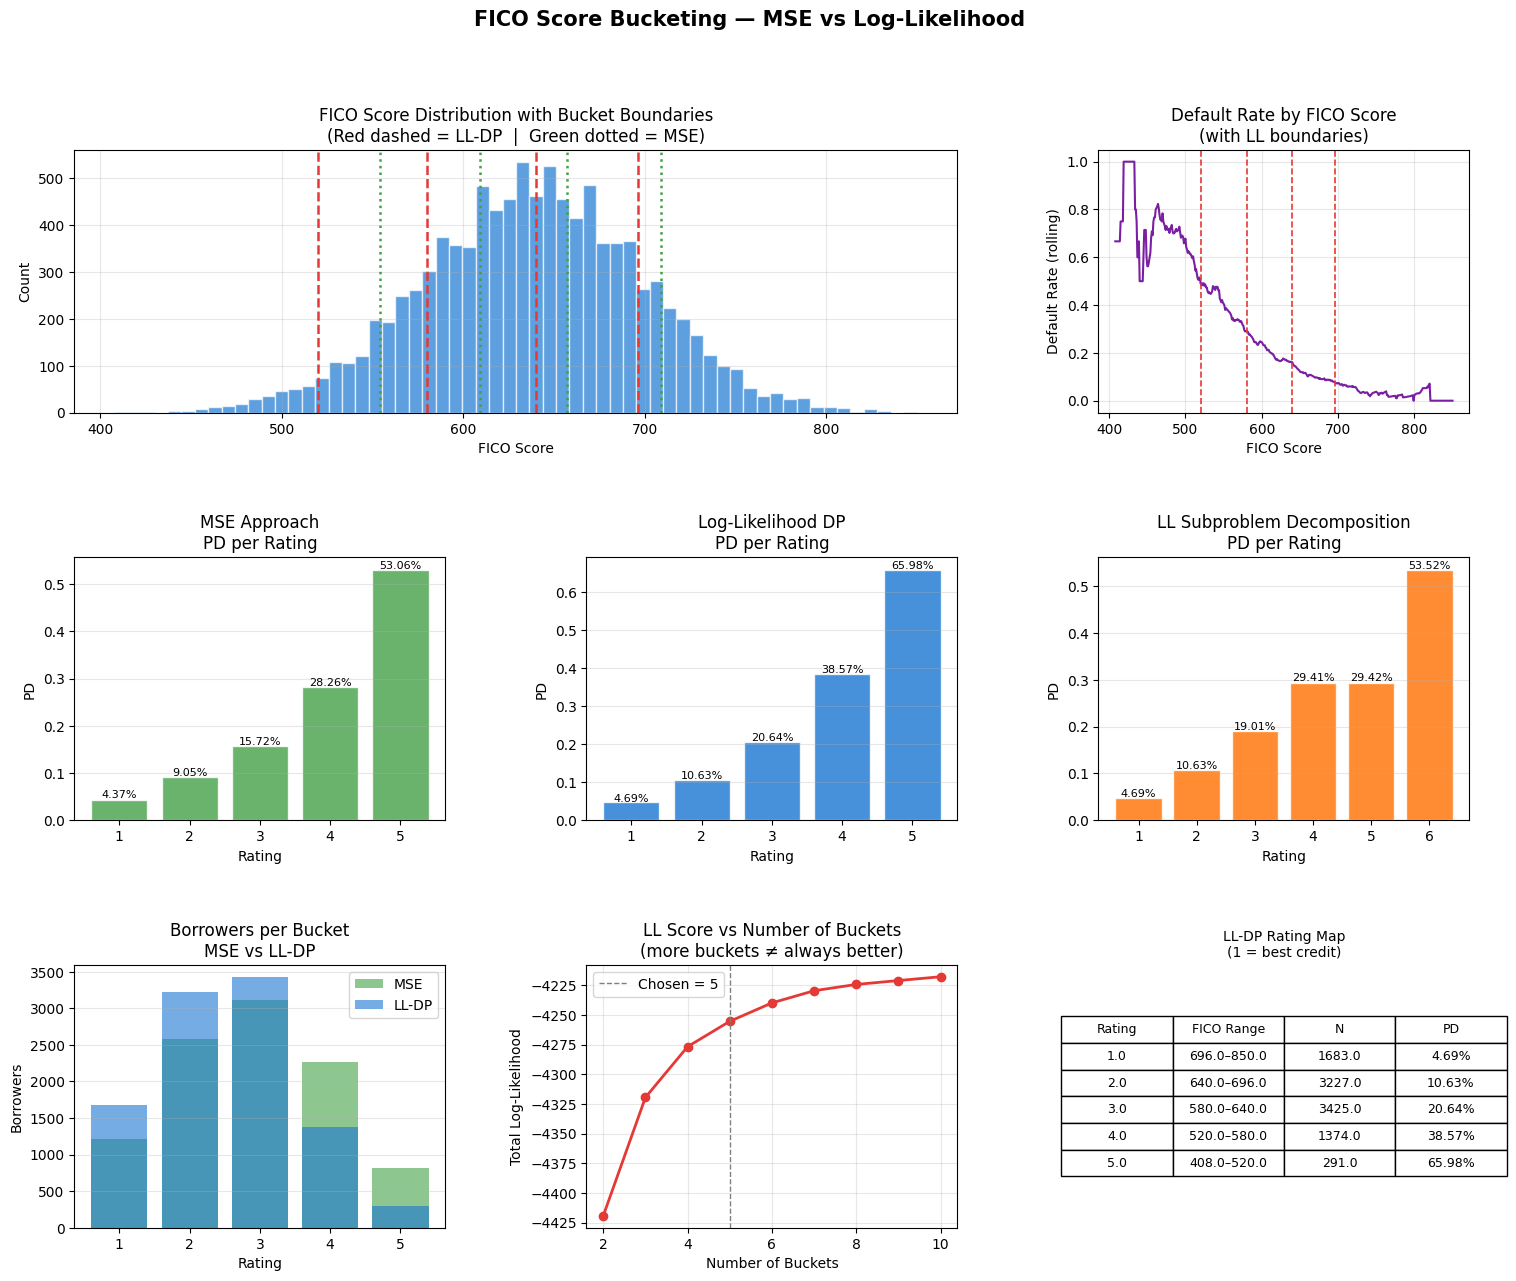

In [17]:

 
 
# ─────────────────────────────────────────
# 8. APPLY RATING MAP TO DATAFRAME
# ─────────────────────────────────────────
def assign_rating(fico_score: int, boundaries: list) -> int:
    """
    Map a single FICO score to a rating using the given boundaries.
    Rating 1 = best credit (highest FICO bucket).
    """
    n = len(boundaries) - 1
    for i in range(n):
        lo = boundaries[i]
        hi = boundaries[i + 1]
        if i < n - 1:
            if lo <= fico_score < hi:
                return n - i       # reverse: high FICO → low rating number
        else:
            if lo <= fico_score <= hi:
                return n - i
    return n  # fallback
 
# Use LL-DP boundaries (best approach) to add rating column to original df
df["fico_rating"] = df["fico_score"].apply(
    lambda s: assign_rating(s, ll_bounds)
)
 
print(f"\n{'─'*65}")
print("  Rating assigned to original dataframe (first 10 rows):")
print(f"{'─'*65}")
print(df[["customer_id", "fico_score", "fico_rating", "default"]].head(10).to_string(index=False))
 
 
# ─────────────────────────────────────────
# 9. SENSITIVITY — DIFFERENT N_BUCKETS
# ─────────────────────────────────────────
print(f"\n{'─'*65}")
print("  Sensitivity: Log-Likelihood vs Number of Buckets")
print(f"{'─'*65}")
 
bucket_range = range(2, 11)
ll_scores    = []
for nb in bucket_range:
    _, ll = ll_bucketing_dp(fico, target, nb)
    ll_scores.append(ll)
    print(f"  {nb} buckets → LL = {ll:.4f}")
 
 
# ─────────────────────────────────────────
# 10. PLOTS
# ─────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle("FICO Score Bucketing — MSE vs Log-Likelihood", fontsize=15, fontweight="bold")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)
 
# ── FICO Distribution ──
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(fico, bins=60, color="#1976D2", alpha=0.7, edgecolor="white")
for b in ll_bounds[1:-1]:
    ax1.axvline(b, color="#E53935", lw=1.8, linestyle="--", label=f"LL bound {b}")
for b in mse_bounds[1:-1]:
    ax1.axvline(b, color="#43A047", lw=1.8, linestyle=":", label=f"MSE bound {b}")
ax1.set_xlabel("FICO Score")
ax1.set_ylabel("Count")
ax1.set_title("FICO Score Distribution with Bucket Boundaries\n(Red dashed = LL-DP  |  Green dotted = MSE)")
ax1.grid(alpha=0.3)
 
# ── Default Rate by FICO (smoothed) ──
ax2 = fig.add_subplot(gs[0, 2])
score_range = np.arange(fico.min(), fico.max() + 1)
dr = []
for s in score_range:
    mask = (fico >= s - 10) & (fico <= s + 10)
    dr.append(target[mask].mean() if mask.sum() > 0 else np.nan)
ax2.plot(score_range, dr, color="#7B1FA2", lw=1.5)
for b in ll_bounds[1:-1]:
    ax2.axvline(b, color="#E53935", lw=1.2, linestyle="--")
ax2.set_xlabel("FICO Score")
ax2.set_ylabel("Default Rate (rolling)")
ax2.set_title("Default Rate by FICO Score\n(with LL boundaries)")
ax2.grid(alpha=0.3)
 
# ── MSE Rating Map ──
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(mse_map["Rating"].astype(str), mse_map["PD"], color="#43A047", alpha=0.8, edgecolor="white")
ax3.set_xlabel("Rating")
ax3.set_ylabel("PD")
ax3.set_title("MSE Approach\nPD per Rating")
ax3.grid(alpha=0.3, axis="y")
for i, row in mse_map.iterrows():
    ax3.text(i, row["PD"] + 0.003, f"{row['PD']:.2%}", ha="center", fontsize=8)
 
# ── LL Rating Map ──
ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(ll_map["Rating"].astype(str), ll_map["PD"], color="#1976D2", alpha=0.8, edgecolor="white")
ax4.set_xlabel("Rating")
ax4.set_ylabel("PD")
ax4.set_title("Log-Likelihood DP\nPD per Rating")
ax4.grid(alpha=0.3, axis="y")
for i, row in ll_map.iterrows():
    ax4.text(i, row["PD"] + 0.003, f"{row['PD']:.2%}", ha="center", fontsize=8)
 
# ── Subproblem Decomposition Map ──
ax5 = fig.add_subplot(gs[1, 2])
ax5.bar(combined_map["Rating"].astype(str), combined_map["PD"], color="#FF6F00", alpha=0.8, edgecolor="white")
ax5.set_xlabel("Rating")
ax5.set_ylabel("PD")
ax5.set_title("LL Subproblem Decomposition\nPD per Rating")
ax5.grid(alpha=0.3, axis="y")
for i, row in combined_map.iterrows():
    ax5.text(i, row["PD"] + 0.003, f"{row['PD']:.2%}", ha="center", fontsize=8)
 
# ── Borrowers per Bucket ──
ax6 = fig.add_subplot(gs[2, 0])
ax6.bar(mse_map["Rating"].astype(str), mse_map["Borrowers"], color="#43A047", alpha=0.6, label="MSE")
ax6.bar(ll_map["Rating"].astype(str),  ll_map["Borrowers"],  color="#1976D2", alpha=0.6, label="LL-DP")
ax6.set_xlabel("Rating")
ax6.set_ylabel("Borrowers")
ax6.set_title("Borrowers per Bucket\nMSE vs LL-DP")
ax6.legend()
ax6.grid(alpha=0.3, axis="y")
 
# ── LL vs Number of Buckets ──
ax7 = fig.add_subplot(gs[2, 1])
ax7.plot(list(bucket_range), ll_scores, "o-", color="#E53935", lw=2)
ax7.axvline(N_BUCKETS, color="gray", lw=1, linestyle="--", label=f"Chosen = {N_BUCKETS}")
ax7.set_xlabel("Number of Buckets")
ax7.set_ylabel("Total Log-Likelihood")
ax7.set_title("LL Score vs Number of Buckets\n(more buckets ≠ always better)")
ax7.legend()
ax7.grid(alpha=0.3)
 
# ── Final Rating Map Table ──
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis("off")
table_data = [
    [str(r["Rating"]), f"{r['FICO Low']}–{r['FICO High']}", str(r["Borrowers"]), f"{r['PD']:.2%}"]
    for _, r in ll_map.iterrows()
]
tbl = ax8.table(
    cellText   = table_data,
    colLabels  = ["Rating", "FICO Range", "N", "PD"],
    loc        = "center",
    cellLoc    = "center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)
ax8.set_title("LL-DP Rating Map\n(1 = best credit)", fontsize=10)
 
plt.savefig("fico_bucketing_results.png", dpi=150, bbox_inches="tight")
print(f"\n[Plots saved to: fico_bucketing_results.png]")
 
 
# ─────────────────────────────────────────
# 11. EXPORT FINAL RATING MAP
# ─────────────────────────────────────────
ll_map.to_csv("fico_rating_map.csv", index=False)
print(f"[Rating map saved to: fico_rating_map.csv]")
df[["customer_id", "fico_score", "fico_rating", "default"]].to_csv("fico_rated_borrowers.csv", index=False)
print(f"[Rated borrowers saved to: fico_rated_borrowers.csv]")
 
print("\n" + "=" * 65)
print("  DONE")
print("=" * 65)